### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [7]:
data = pd.read_csv("data/coupons.csv")

In [8]:
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

Number of null entries in each column

In [9]:
data.isnull().sum()

,0
destination,0
passanger,0
weather,0
temperature,0
time,0
coupon,0
expiration,0
gender,0
age,0
maritalStatus,0


3. Decide what to do about your missing data -- drop, replace, other...

**Step1: Drop a column where the proportion of null values is greater than 35%**

In [10]:
for i in range(data.shape[1]-1):
  if(data.isnull().sum()[i]> 0 and data.isnull().sum()[i]/data.shape[0] > 0.35):
    data.drop(data.columns[i], axis=1, inplace=True)
data.shape

/tmp/ipykernel_21753/2748555350.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if(data.isnull().sum()[i]> 0 and data.isnull().sum()[i]/data.shape[0] > 0.35):
/tmp/ipykernel_21753/2748555350.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if(data.isnull().sum()[i]> 0 and data.isnull().sum()[i]/data.shape[0] > 0.35):


(12684, 25)

**Step2: Change dtype for column "age" to int**

See what values the age column have

In [60]:
data.age.value_counts()

,count
age,
21,2653
26,2559
31,2039
50plus,1788
36,1319
41,1093
46,686
below21,547


First we need to replace the value 50plus with 51 and below21 with 20

In [11]:
data['age']=data['age'].replace({"50plus": "51", "below21": "20"})


change the type to int now

In [12]:
data.age = data.age.astype(int)

4. What proportion of the total observations chose to accept the coupon?



In [15]:
overallAcceptanceRate = data.query("Y == 1").shape[0]/data.shape[0]

print(f"Overall Acceptance Rate: {overallAcceptanceRate:.2%}")

Overall Acceptance Rate: 56.84%


In the given dataset more than 56% drivers accepted the coupons.

5. Use a bar plot to visualize the `coupon` column.

Text(0.5, 1.0, 'Acceptance by coupon type')

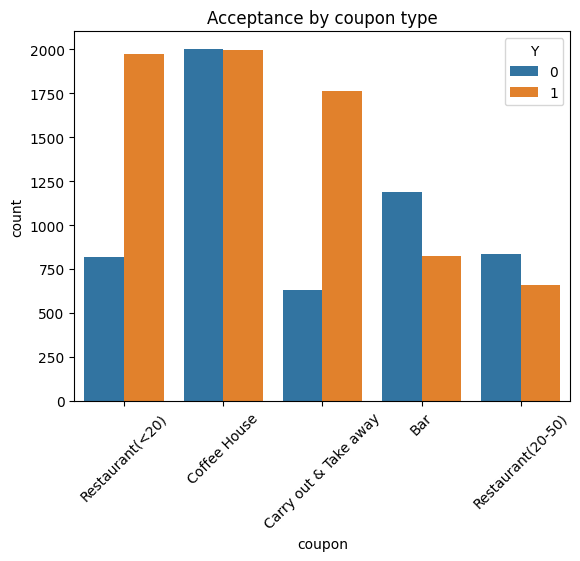

In [64]:
sns.countplot(x='coupon', hue='Y', data=data)
plt.xticks(rotation=45)
plt.title("Acceptance by coupon type")

**Coffee House coupons :** Acceptance Rate is almost 50% were accepted.

**Restaurant(less expensive) coupons :** Acceptance rate is less than 30%

**Carry out & Take Away coupons :** Acceptance rate is less than 30%

**Bar coupons :** Acceptance rate is between 30-50%

**Rastaurant(expensive) coupons :** Acceptance rate is between 30-50%

**So the highest acceptace Rate is observed for CoffeeHouse coupons**

6. Use a histogram to visualize the temperature column.

Text(0.5, 1.0, 'Acceptance by temperature')

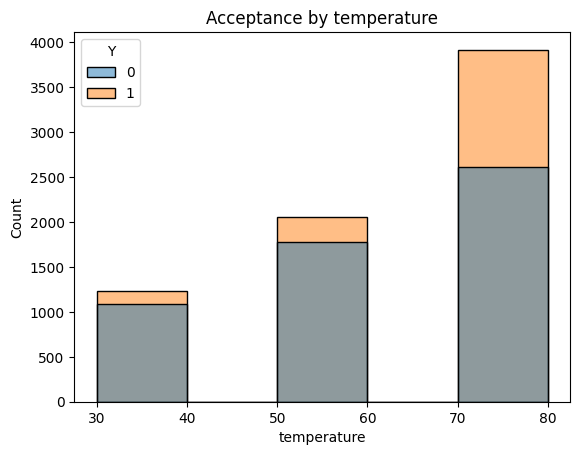

In [65]:
sns.histplot(data=data, x='temperature', bins=5, hue='Y')
plt.title("Acceptance by temperature")

**Conclusion :  Acceptance rate is more where temperature is between 70-80 degrees**

**Investigate impact of expiration on overall acceptance**

Text(0.5, 1.0, 'Acceptance by expiration')

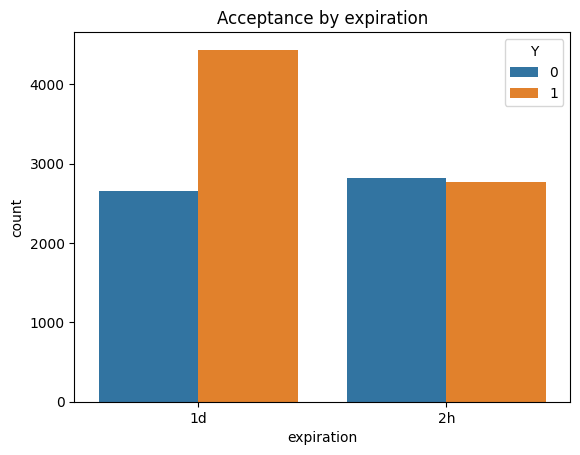

In [66]:
sns.countplot(x='expiration', hue='Y', data=data)
plt.title("Acceptance by expiration")

**Investigate impact of destination type on overall acceptance**

Text(0.5, 1.0, 'Acceptance by destination')

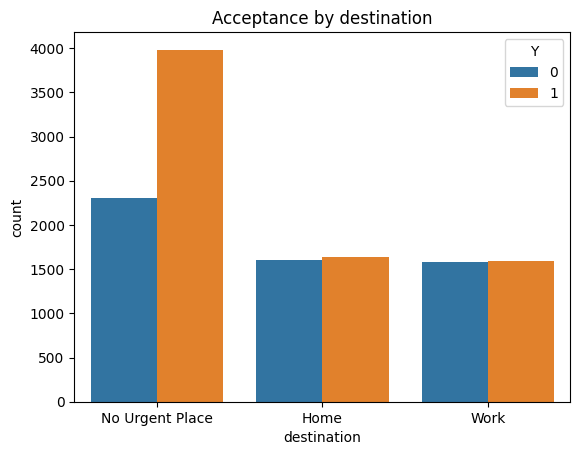

In [67]:
sns.countplot(x='destination', hue='Y', data=data)
plt.title("Acceptance by destination")

**Investigate impact of income on acceptance**:

Text(0.5, 1.0, 'Inpact of income')

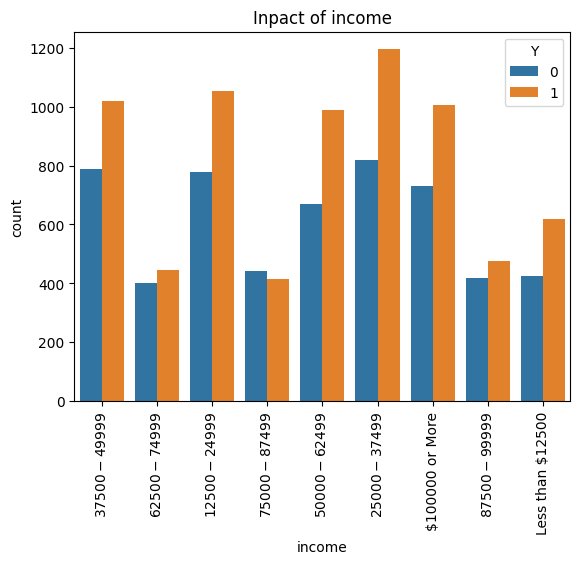

In [19]:
sns.countplot(x='income', hue='Y', data=data)
plt.xticks(rotation=90)
plt.title("Impact of income")

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [22]:
data_bar = data[data.coupon == "Bar"]
data_bar.shape

(2017, 25)

2. What proportion of bar coupons were accepted?


In [24]:
barCpAccepted = data_bar.Y.value_counts()[1]/data_bar.shape[0]
print(f"Bar coupons Acceptance Rate: {barCpAccepted:.2%}")

Bar coupons Acceptance Rate: 41.00%


**41% of bar coupons were accepted**

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [26]:
data_bar.Bar.value_counts()
bar_visit_3orLess = ["1~3", "never", "less1"]
AcceptanceRate_barVisit_3orLess = data_bar.query("Y==1 and Bar in @bar_visit_3orLess").shape[0]/data_bar.shape[0]

AcceptanceRate_barVisit_MoreThan3 = data_bar.query("Y==1 and Bar not in @bar_visit_3orLess").shape[0]/data_bar.shape[0]

print(f"AcceptanceRate_barVisit_3orLess = {AcceptanceRate_barVisit_3orLess:.2%}")
print(f"AcceptanceRate_barVisit_MoreThan3 = {AcceptanceRate_barVisit_MoreThan3:.2%}")

AcceptanceRate_barVisit_3orLess = 33.02%
AcceptanceRate_barVisit_MoreThan3 = 7.98%


**Drivers who went to bar 3 times or less in a month are more than 4 times more likely to accept the coupon as compared to those who went to bar more than 3 times **

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [28]:
bar_visit_1orMore = ["4~8", "1~3", "gt8"]
df_MoreThan25AndBar1orMore = data_bar.query("age > 25 and Bar in @bar_visit_1orMore")
acceptRate4a = df_MoreThan25AndBar1orMore.Y.value_counts()[1]/df_MoreThan25AndBar1orMore.shape[0]
print(f"Acceptance Rate for age>25 and bar visit >1 : {acceptRate4a:.2%}")

bar_visit_LessThan1 = ["less1", "Never"]
df_LessThan25AndBarlessThan1 = data_bar.query("age < 25 and Bar in @bar_visit_LessThan1")

acceptRate4b = df_LessThan25AndBarlessThan1.Y.value_counts()[1]/df_LessThan25AndBarlessThan1.shape[0]
print(f"Acceptance Rate for age<25 and bar visit <1 : {acceptRate4b:.2%}")

Acceptance Rate for age>25 and bar visit >1 : 69.52%
Acceptance Rate for age<25 and bar visit <1 : 58.33%


**This indicates that the drivers who are aged 25 years or more and visit bar more than once are a little more likely to accept the coupon**

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [29]:
passengerType = ["Friend(s)","Partner","Alone" ]
occupationFFF = ["Farming Fishing & Forestry"]
selected_df = data_bar.query("passanger in @passengerType and Bar in @bar_visit_1orMore and occupation not in @occupationFFF")
acceptedRateWithAdultPassenger = selected_df.Y.value_counts()[1]/data_bar.shape[0]
print(f"Acceptace rate with adult passengser and occupation FFF : {acceptedRateWithAdultPassenger:.2%}")

Acceptace rate with adult passengser and occupation FFF : 19.48%


Acceptance rate in this subset is 19.48%

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [30]:
#Fetch subset1 where drivers go to bars more than once a month,
#had passengers that were not a kid, and were not widowed
widowDrivers = ["Widowed"]
cheapRestaurantVisit = ["4~8", "gt8"]
incomeRanges = ["Less than $12500", "$12500 - $24999","$25000 - $37499", "$37500 - $49999"]
subset1 = data_bar.query("passanger in @passengerType and Bar in @bar_visit_1orMore and maritalStatus not in @widowDrivers").reset_index()
acceptRate_in_subset1 = subset1.Y.value_counts()[1]/subset1.shape[0]

#Fetch subset2 where drivers go to bars more than once a month and are under the age of 30
subset2 = data_bar.query("Bar in @bar_visit_1orMore and age < 30").reset_index()
acceptRate_in_subset2 = subset2.Y.value_counts()[1]/subset2.shape[0]

#Fetch subset3 where drivers go to cheap restaurants more than 4 times a month and income is less than 50K
subset3 = data_bar.query("RestaurantLessThan20 in @cheapRestaurantVisit and income in @incomeRanges").reset_index()
acceptRate_in_subset3 = subset3.Y.value_counts()[1]/subset3.shape[0]

print(f"Subset 1 : {acceptRate_in_subset1:.2%}","vs",f"Subset 2 : {acceptRate_in_subset2:.2%}","vs",f"Subset 3 : {acceptRate_in_subset3:.2%}")

Subset 1 : 71.32% vs Subset 2 : 72.17% vs Subset 3 : 45.35%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

**Overall 41% of bar coupons were accepted**

**Acceptance rate is higher than 70% when:**

Pasanger is not Kid OR
when bar visits are more than 1 and age less than 30

**Acceptance rate dips to ~45% when:**

the driver visits to cheap restaurants frequently and income is less than 50K

**Acceptance rate dips to as low as 19% when** passanger is not kid and driver is not working in Farming Fishing & Forestry

**Acceptance of bar coupons is less than 10%** for drivers who visit bar more than 3 times

**HYPOTHESIS:**
Drivers are most likely to accept BAR COUPONS if they are not frequent bar goers, and travelling with an adult, age less than 30 and do not work in
Fishing, farming and forestery.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

**Exploring "Restaurant(20-50)" coupons**

In [37]:
data_expensiveRestaurant = data[data.coupon == "Restaurant(20-50)"]

<class 'pandas.core.frame.DataFrame'>
Index: 1492 entries, 14 to 12683
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           1492 non-null   object
 1   passanger             1492 non-null   object
 2   weather               1492 non-null   object
 3   temperature           1492 non-null   int64 
 4   time                  1492 non-null   object
 5   coupon                1492 non-null   object
 6   expiration            1492 non-null   object
 7   gender                1492 non-null   object
 8   age                   1492 non-null   int64 
 9   maritalStatus         1492 non-null   object
 10  has_children          1492 non-null   int64 
 11  education             1492 non-null   object
 12  occupation            1492 non-null   object
 13  income                1492 non-null   object
 14  Bar                   1482 non-null   object
 15  CoffeeHouse           1465 non-null   obj

In [41]:
# Overall acceptance rate for this group
expRestaurantAcceptanceRate = data_expensiveRestaurant['Y'].mean()
print(f"Acceptance rate for Expensive Restaurant coupons: {expRestaurantAcceptanceRate:.2%}")

Acceptance rate for Expensive Restaurant coupons: 44.10%


**Overall acceptance rate of "Restaurant(20-50)" coupons is over 44%**

<Axes: xlabel='Restaurant20To50', ylabel='Y'>

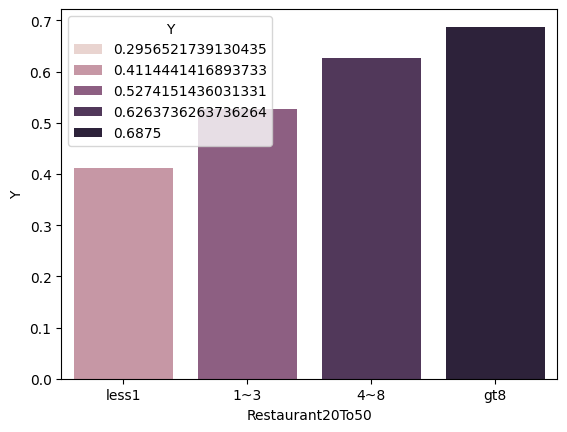

In [56]:
orderby = ['less1', '1~3', '4~8', 'gt8']
sns.barplot(data=data_expensiveRestaurant[["Restaurant20To50", "Y"]].groupby("Restaurant20To50").mean()[['Y']], x='Restaurant20To50', y='Y', order=orderby, hue='Y')

**Conclusion: Acceptance rate increases with number of visits to expensive restaurants**

/tmp/ipykernel_21753/2030371735.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_expensiveRestaurant[["time", "Y"]].groupby("time").mean()[['Y']], x='time', y='Y', order=time_order, palette='coolwarm', ax=axes[0, 1], errorbar=None)
/tmp/ipykernel_21753/2030371735.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_expensiveRestaurant[["passanger", "Y"]].groupby("passanger").mean()[['Y']], x='passanger', y='Y', palette='muted', ax=axes[1, 0], errorbar=None)
/tmp/ipykernel_21753/2030371735.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same

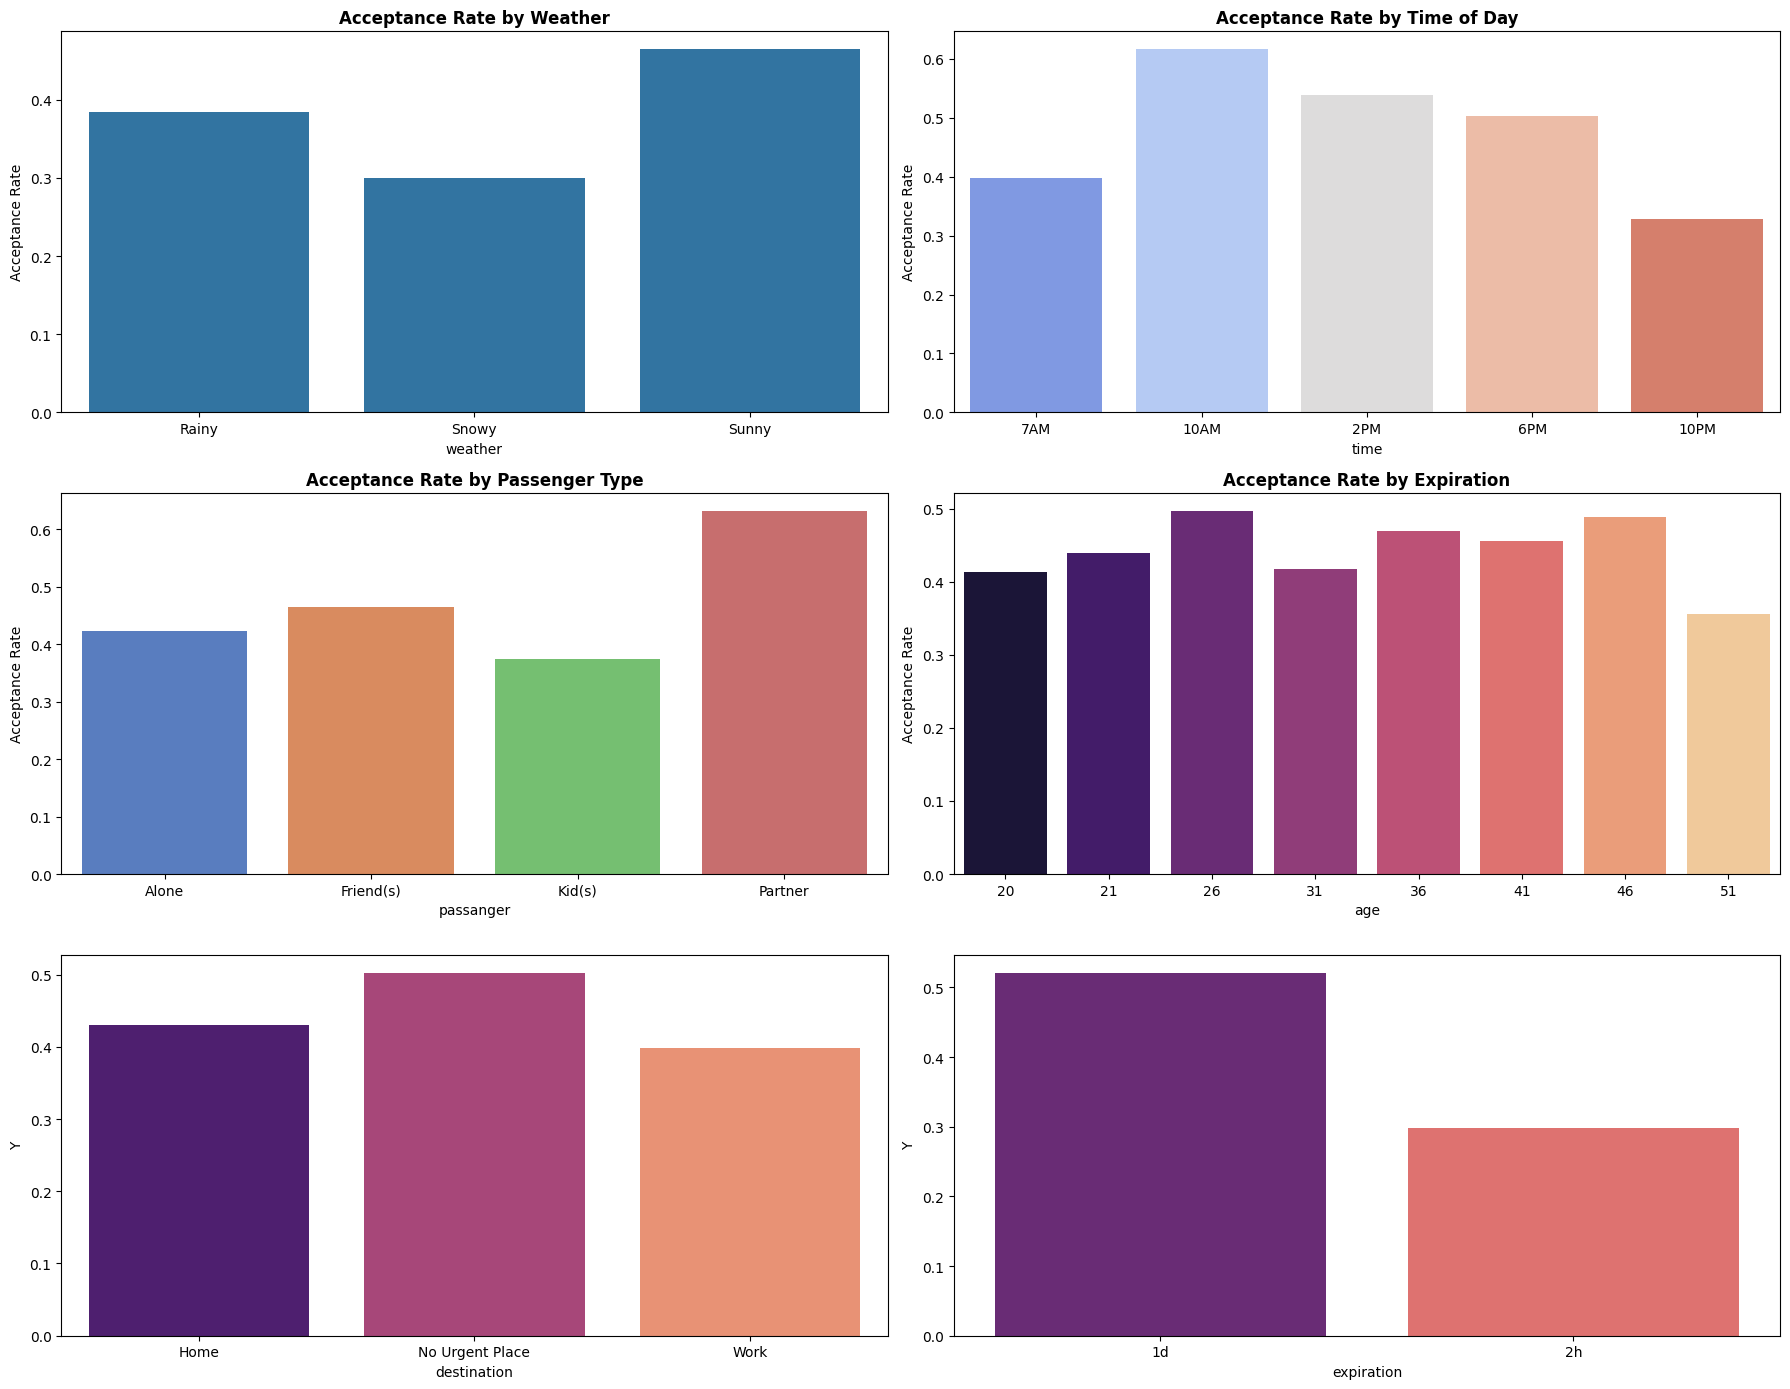

In [64]:
fig, axes = plt.subplots(3, 2, figsize=(18, 14))

# Acceptance by Weather
sns.barplot(data=data_expensiveRestaurant[["weather", "Y"]].groupby("weather").mean()[['Y']], x='weather', y='Y', ax=axes[0, 0], errorbar=None)
axes[0, 0].set_title('Acceptance Rate by Weather', fontweight='bold')
axes[0, 0].set_ylabel('Acceptance Rate')

# Acceptance by Time
time_order = ['7AM', '10AM', '2PM', '6PM', '10PM']
sns.barplot(data=data_expensiveRestaurant[["time", "Y"]].groupby("time").mean()[['Y']], x='time', y='Y', order=time_order, palette='coolwarm', ax=axes[0, 1], errorbar=None)
axes[0, 1].set_title('Acceptance Rate by Time of Day', fontweight='bold')
axes[0, 1].set_ylabel('Acceptance Rate')

# Acceptance by Passenger Type
sns.barplot(data=data_expensiveRestaurant[["passanger", "Y"]].groupby("passanger").mean()[['Y']], x='passanger', y='Y', palette='muted', ax=axes[1, 0], errorbar=None)
axes[1, 0].set_title('Acceptance Rate by Passenger Type', fontweight='bold')
axes[1, 0].set_ylabel('Acceptance Rate')

# Acceptance by Age
age_order = [20, 21, 26, 31, 36, 41, 46, 51]
sns.barplot(data=data_expensiveRestaurant[["age", "Y"]].groupby("age").mean()[['Y']], x='age', y='Y', order=age_order, palette='magma', ax=axes[1, 1], errorbar=None)
axes[1, 1].set_title('Acceptance Rate by Age Group', fontweight='bold')
axes[1, 1].set_ylabel('Acceptance Rate')

# Acceptance by destination
sns.barplot(data=data_expensiveRestaurant[["destination", "Y"]].groupby("destination").mean()[['Y']], x='destination', y='Y', palette='magma', ax=axes[2, 0], errorbar=None)
axes[1, 1].set_title('Acceptance Rate by Destination', fontweight='bold')
axes[1, 1].set_ylabel('Acceptance Rate')

# Acceptance by expiration
sns.barplot(data=data_expensiveRestaurant[["expiration", "Y"]].groupby("expiration").mean()[['Y']], x='expiration', y='Y', palette='magma', ax=axes[2, 1], errorbar=None)
axes[1, 1].set_title('Acceptance Rate by Expiration', fontweight='bold')
axes[1, 1].set_ylabel('Acceptance Rate')

plt.tight_layout()

**Hypothesis: Drivers are most likely to accept coupons for Expensive Restaurants, when it is a sunny morning, they are driving with their partner neither to work nor home and coupon has longer expiry of 1day**

**Exploring "Restaurant(<20)" coupons**

In [80]:
#Fetch the subset
data_cheapRestaurant = data[data.coupon == "Restaurant(<20)"]

In [81]:
# Overall acceptance rate for this group
cheapRestaurantAcceptanceRate = data_cheapRestaurant['Y'].mean()
print(f"Acceptance rate for Cheap Restaurant coupons: {cheapRestaurantAcceptanceRate:.2%}")

Acceptance rate for Cheap Restaurant coupons: 70.71%


**Overall acceptance rate of "Restaurant(<20)" coupons is over 70%**

<Axes: xlabel='RestaurantLessThan20', ylabel='Y'>

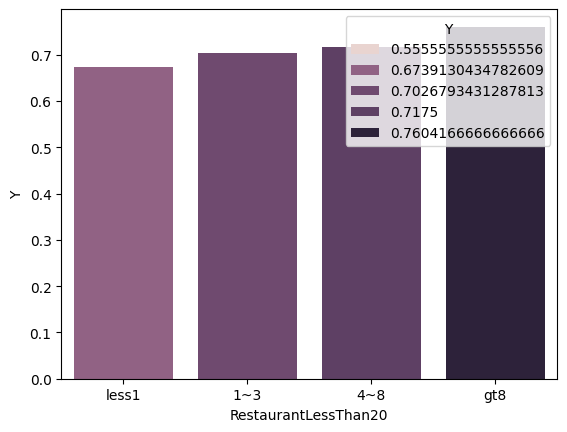

In [82]:
orderby = ['less1', '1~3', '4~8', 'gt8']
sns.barplot(data=data_cheapRestaurant[["RestaurantLessThan20", "Y"]].groupby("RestaurantLessThan20").mean()[['Y']], x='RestaurantLessThan20', y='Y', order=orderby, hue='Y')

**Conclusion: Acceptance rate increases with number of visits to cheap restaurants**

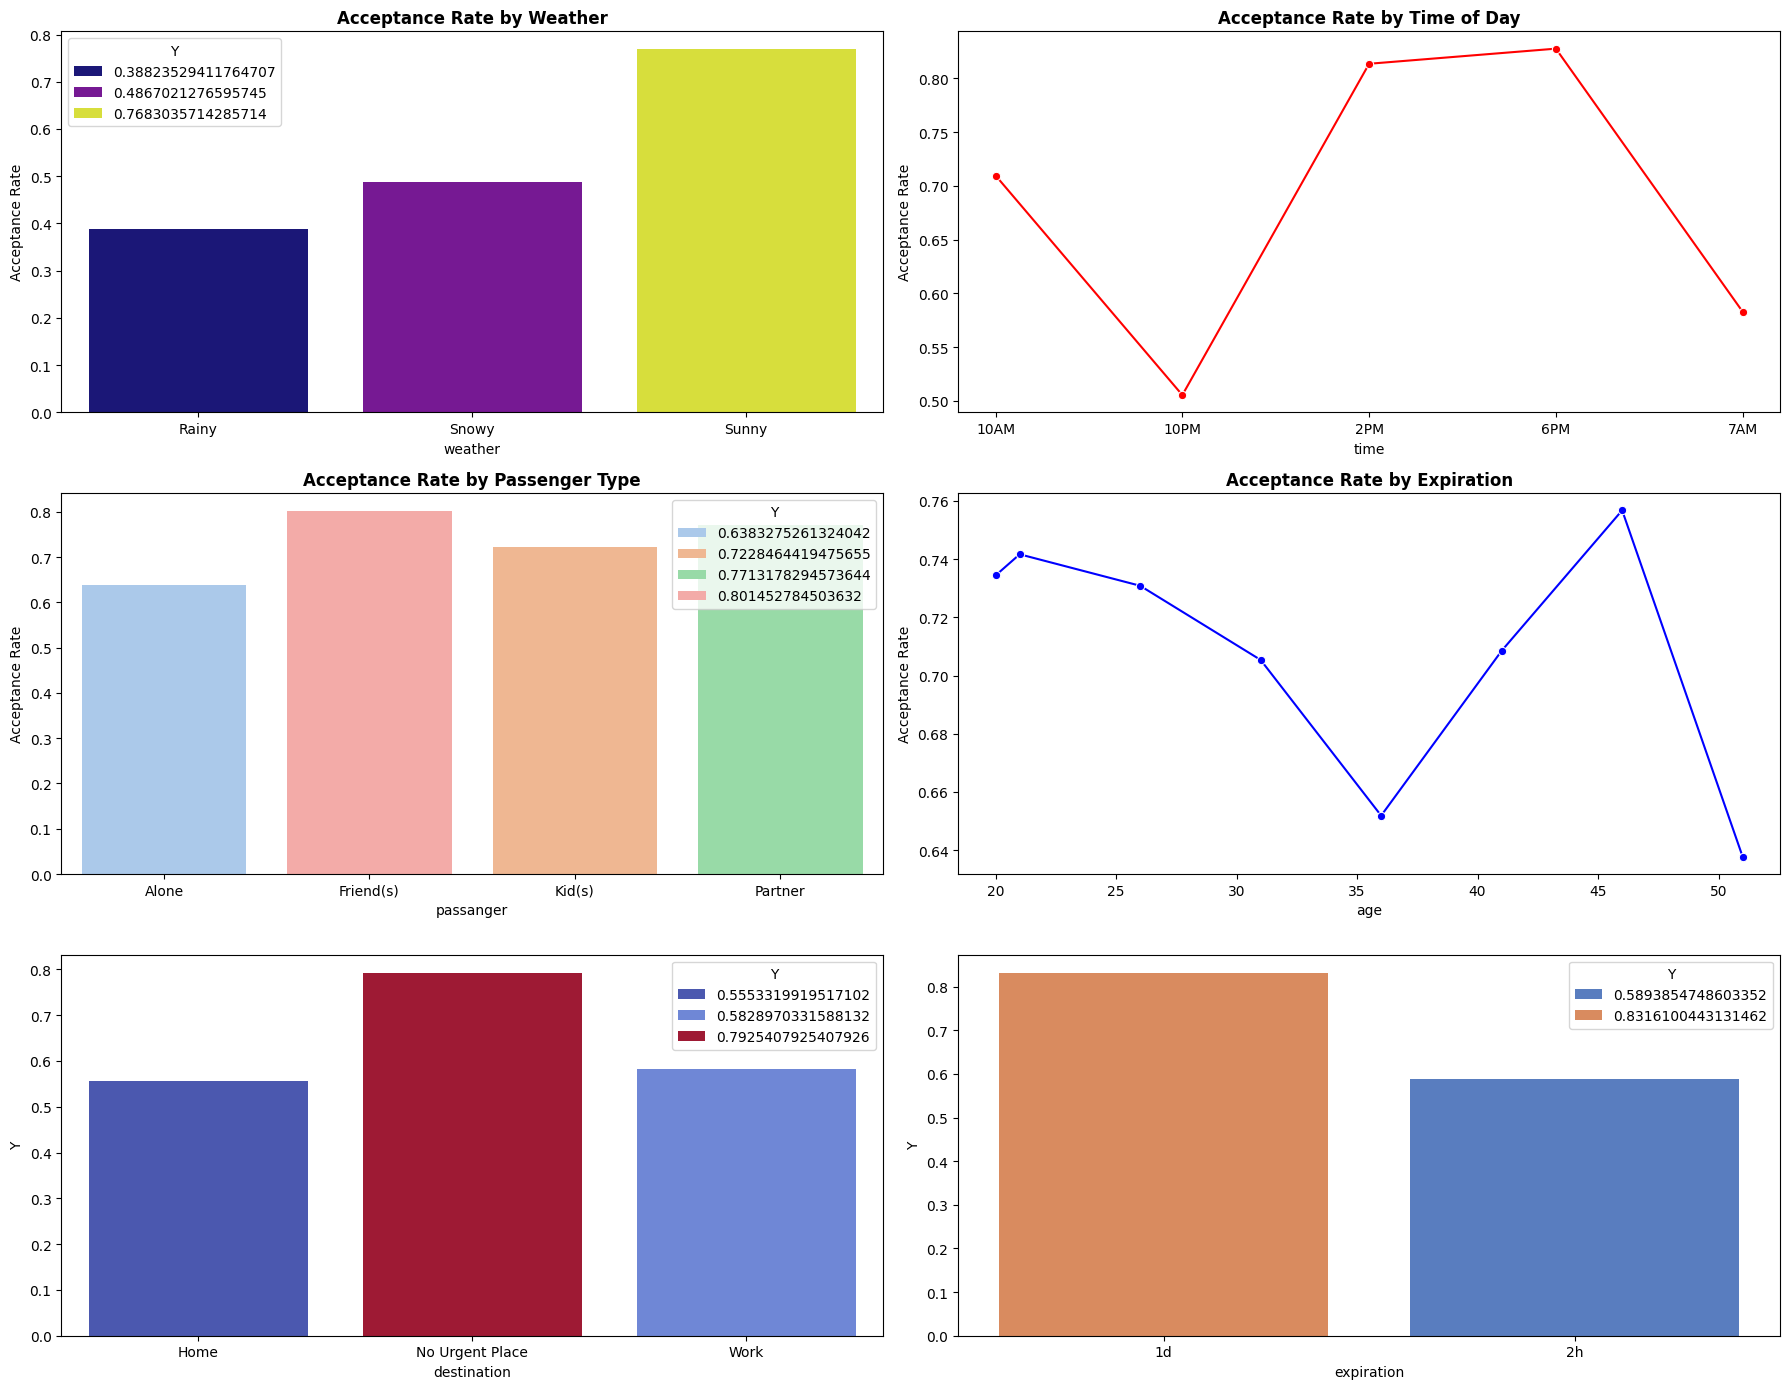

In [85]:
fig, axes = plt.subplots(3, 2, figsize=(18, 14))

# Acceptance by Weather
sns.barplot(data=data_cheapRestaurant[["weather", "Y"]].groupby("weather").mean()[['Y']], x='weather', y='Y', palette='plasma' , hue="Y", ax=axes[0, 0], errorbar=None)
axes[0, 0].set_title('Acceptance Rate by Weather', fontweight='bold')
axes[0, 0].set_ylabel('Acceptance Rate')

# Acceptance by Time
time_order = ['7AM', '10AM', '2PM', '6PM', '10PM']
sns.lineplot(data=data_cheapRestaurant[["time", "Y"]].groupby("time").mean()[['Y']], x='time', y='Y', color='r', marker='o', ax=axes[0, 1], errorbar=None)
axes[0, 1].set_title('Acceptance Rate by Time of Day', fontweight='bold')
axes[0, 1].set_ylabel('Acceptance Rate')

# Acceptance by Passenger Type
sns.barplot(data=data_cheapRestaurant[["passanger", "Y"]].groupby("passanger").mean()[['Y']], x='passanger', y='Y', palette='pastel', hue="Y", ax=axes[1, 0], errorbar=None)
axes[1, 0].set_title('Acceptance Rate by Passenger Type', fontweight='bold')
axes[1, 0].set_ylabel('Acceptance Rate')

# Acceptance by Age
age_order = [20, 21, 26, 31, 36, 41, 46, 51]
sns.lineplot(data=data_cheapRestaurant[["age", "Y"]].groupby("age").mean()[['Y']], x='age', y='Y', color='b', marker='o', ax=axes[1, 1], errorbar=None)
axes[1, 1].set_title('Acceptance Rate by Age Group', fontweight='bold')
axes[1, 1].set_ylabel('Acceptance Rate')

# Acceptance by destination
sns.barplot(data=data_cheapRestaurant[["destination", "Y"]].groupby("destination").mean()[['Y']], x='destination', y='Y', palette='coolwarm', hue="Y", ax=axes[2, 0], errorbar=None)
axes[1, 1].set_title('Acceptance Rate by Destination', fontweight='bold')
axes[1, 1].set_ylabel('Acceptance Rate')

# Acceptance by expiration
sns.barplot(data=data_cheapRestaurant[["expiration", "Y"]].groupby("expiration").mean()[['Y']], x='expiration', y='Y', palette='muted', hue="Y", ax=axes[2, 1], errorbar=None)
axes[1, 1].set_title('Acceptance Rate by Expiration', fontweight='bold')
axes[1, 1].set_ylabel('Acceptance Rate')

plt.tight_layout()

**Hypothesis: Drivers are most likely to accept coupons for Cheap Restaurants, when it is a sunny afternoon or evenings, they are driving with their partner or friend neither to work nor home and coupon has longer expiry of 1day**